In [19]:
# Cell 0: Install seaborn (run this first)
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [20]:
# Cell 1: Import Libraries
import argparse
import os
from pathlib import Path
from urllib.parse import quote_plus
import warnings
warnings.filterwarnings('ignore')

import joblib
import numpy as np
import pandas as pd
from sqlalchemy import create_engine, text
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, roc_curve, auc, precision_recall_curve
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


In [21]:
# Cell 2: Configuration
DEFAULT_OUTPUT_DIR = Path("model_outputs")
RANDOM_STATE = 42
FEATURE_COLUMNS = [
    "source_system",
    "temperature_celsius",
    "pressure_bar",
    "rpm",
    "vibration",
    "current_amps",
    "torque_nm",
    "tool_wear_min",
]

# Database configuration (update password if needed)
DB_PASSWORD = "1234"  # Change this to your password
DB_USER = "postgres"
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "predictive_maintenance_dwh"

print("Configuration loaded!")

Configuration loaded!


In [24]:
!pip install psycopg2-binary

   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.8 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.8 MB ? eta -:--:--
   ------- -------------------------------- 0.5/2.8 MB 1.0 MB/s eta 0:00:03
   ----------- ---------------------------- 0.8/2.8 MB 958.5 kB/s eta 0:00:03
   ----------- ---------------------------- 0.8/2.8 MB 958.5 kB/s eta 0:00:03
   --------------- ------------------------ 1.0/2.8 MB 812.4 kB/s eta 0:00:03
   --------------- ------------------------ 1.0/2.8 MB 812.4 kB/s eta 0:00:03
   ------------------- -------------------- 1.3/2.8 MB 799.2 kB/s eta 0:00:02
   ---------------------- ----------------- 1.6/2.8 MB 769.7 kB/s eta 0:00:02
   ---------------------- ----------------

In [25]:
# Cell 3: Database Connection Function
def get_database_url() -> str:
    """Build the database URL"""
    from urllib.parse import quote_plus
    password = quote_plus(DB_PASSWORD)
    return f"postgresql://{DB_USER}:{password}@{DB_HOST}:{DB_PORT}/{DB_NAME}"

def load_warehouse_data(limit: int | None = None) -> pd.DataFrame:
    """Load data from the warehouse"""
    query = """
        SELECT
            measurement_id,
            equipment_key,
            time_key,
            source_system,
            temperature_celsius,
            pressure_bar,
            rpm,
            vibration,
            current_amps,
            torque_nm,
            tool_wear_min,
            label_binary,
            failure_type
        FROM maintenance.FactSensorReadings
        WHERE label_binary IS NOT NULL
    """
    
    if limit:
        query += " LIMIT :limit"
    
    engine = create_engine(get_database_url())
    with engine.connect() as conn:
        return pd.read_sql(text(query), conn, params={"limit": limit} if limit else None)

# Test connection
try:
    test_df = load_warehouse_data(limit=5)
    print(f" Database connected successfully!")
    print(f"Sample data shape: {test_df.shape}")
    print(f"Columns: {test_df.columns.tolist()}")
except Exception as e:
    print(f" Connection failed: {e}")

 Database connected successfully!
Sample data shape: (5, 13)
Columns: ['measurement_id', 'equipment_key', 'time_key', 'source_system', 'temperature_celsius', 'pressure_bar', 'rpm', 'vibration', 'current_amps', 'torque_nm', 'tool_wear_min', 'label_binary', 'failure_type']


In [26]:
# Cell 4: Load Data
# Choose data source
USE_DEMO = False  # Set to True for demo data, False for real database
LIMIT_ROWS = None  # Set to number like 10000 to limit rows, None for all

if USE_DEMO:
    from sklearn.utils import resample
    # Create demo data
    rng = np.random.default_rng(RANDOM_STATE)
    n_rows = 1200
    source_system = rng.choice(["AI4I", "MetroPT3", "Pump"], size=n_rows, p=[0.4, 0.25, 0.35])
    
    data = pd.DataFrame({
        "measurement_id": np.arange(1, n_rows + 1),
        "equipment_key": rng.integers(1, 45, size=n_rows),
        "time_key": 2024010100 + np.arange(n_rows),
        "source_system": source_system,
        "temperature_celsius": rng.normal(62, 18, size=n_rows),
        "pressure_bar": rng.normal(8.5, 3.2, size=n_rows),
        "rpm": rng.normal(1550, 420, size=n_rows),
        "vibration": rng.normal(2.2, 1.1, size=n_rows),
        "current_amps": rng.normal(5.2, 1.8, size=n_rows),
        "torque_nm": rng.normal(40, 12, size=n_rows),
        "tool_wear_min": rng.normal(105, 62, size=n_rows),
    })
    
    risk_score = (0.035 * (data["temperature_celsius"] - 65) + 0.45 * (data["vibration"] - 2.5) +
                  0.003 * (data["tool_wear_min"] - 120) + 0.0009 * np.maximum(data["rpm"] - 1900, 0) +
                  0.12 * np.maximum(data["pressure_bar"] - 11, 0) + rng.normal(0, 0.65, size=n_rows))
    probability = 1 / (1 + np.exp(-risk_score))
    data["label_binary"] = (probability >= 0.58).astype(int)
    data["failure_type"] = np.where(data["label_binary"].eq(1), "Demo_Failure", None)
    data_source = "demo"
    print(" Using DEMO data")
else:
    data = load_warehouse_data(limit=LIMIT_ROWS)
    data_source = "warehouse"
    print(f" Loaded {len(data):,} rows from database")

print(f"\nData shape: {data.shape}")
print(f"Failure rate: {data['label_binary'].mean()*100:.2f}%")
print(f"\nFirst few rows:")
data.head()

 Loaded 1,546,948 rows from database

Data shape: (1546948, 13)
Failure rate: 0.67%

First few rows:


,measurement_id,equipment_key,time_key,source_system,temperature_celsius,pressure_bar,rpm,vibration,current_amps,torque_nm,tool_wear_min,label_binary,failure_type
0,1,1,2024010100,AI4I,24.95,NaN,1551.0,NaN,NaN,42.8,0.0,0,None
1,2,1,2024010101,AI4I,25.05,NaN,1408.0,NaN,NaN,46.3,3.0,0,None
2,3,1,2024010102,AI4I,24.95,NaN,1498.0,NaN,NaN,49.4,5.0,0,None
3,4,1,2024010103,AI4I,25.05,NaN,1433.0,NaN,NaN,39.5,7.0,0,None
4,5,1,2024010104,AI4I,25.05,NaN,1408.0,NaN,NaN,40.0,9.0,0,None


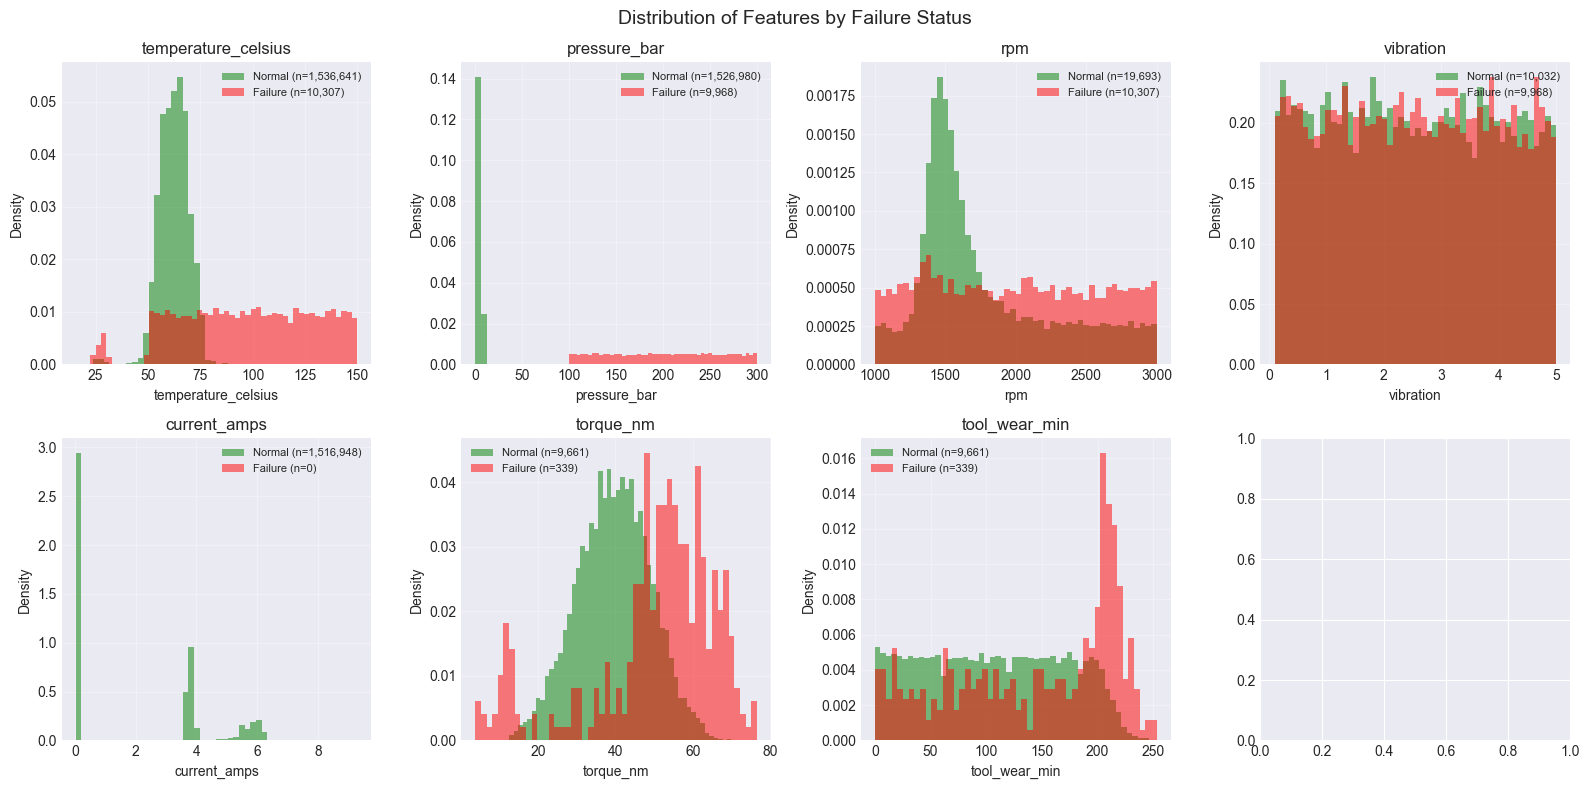

In [31]:
# Cell 5: Exploratory Data Analysis (Fixed)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

numeric_cols = ['temperature_celsius', 'pressure_bar', 'rpm', 'vibration', 'current_amps', 'torque_nm', 'tool_wear_min']

for idx, col in enumerate(numeric_cols):
    # Get data and drop NaN values
    normal_data = data[data['label_binary']==0][col].dropna()
    failure_data = data[data['label_binary']==1][col].dropna()
    
    # Plot histograms
    axes[idx].hist(normal_data, bins=50, alpha=0.5, label=f'Normal (n={len(normal_data):,})', color='green', density=True)
    axes[idx].hist(failure_data, bins=50, alpha=0.5, label=f'Failure (n={len(failure_data):,})', color='red', density=True)
    axes[idx].set_title(f'{col}')
    axes[idx].legend(fontsize=8)
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Density')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Distribution of Features by Failure Status', fontsize=14)
plt.tight_layout()
plt.show()

In [32]:
# # Cell 5: Exploratory Data Analysis (with error handling)
# fig, axes = plt.subplots(2, 4, figsize=(16, 8))
# axes = axes.ravel()

# numeric_cols = ['temperature_celsius', 'pressure_bar', 'rpm', 'vibration', 'current_amps', 'torque_nm', 'tool_wear_min']

# # Check if we have failure cases
# failure_exists = (data['label_binary'] == 1).any()
# print(f"Failure cases present: {failure_exists}")
# print(f"Number of failures: {(data['label_binary'] == 1).sum()}")
# print(f"Number of normal cases: {(data['label_binary'] == 0).sum()}")

# for idx, col in enumerate(numeric_cols):
#     # Get data for normal and failure
#     normal_data = data[data['label_binary'] == 0][col].dropna()
#     failure_data = data[data['label_binary'] == 1][col].dropna()
    
#     # Plot normal data (always available)
#     if len(normal_data) > 0:
#         axes[idx].hist(normal_data, bins=30, alpha=0.5, label='Normal', color='green')
    
#     # Plot failure data only if it exists
#     if len(failure_data) > 0:
#         axes[idx].hist(failure_data, bins=30, alpha=0.5, label='Failure', color='red')
#     else:
#         axes[idx].text(0.5, 0.5, 'No failure data available', 
#                       transform=axes[idx].transAxes, ha='center', va='center')
    
#     axes[idx].set_title(f'{col}')
#     axes[idx].legend()
#     axes[idx].set_xlabel(col)
#     axes[idx].set_ylabel('Frequency')

# plt.suptitle('Distribution of Features by Failure Status', fontsize=14)
# plt.tight_layout()
# plt.show()

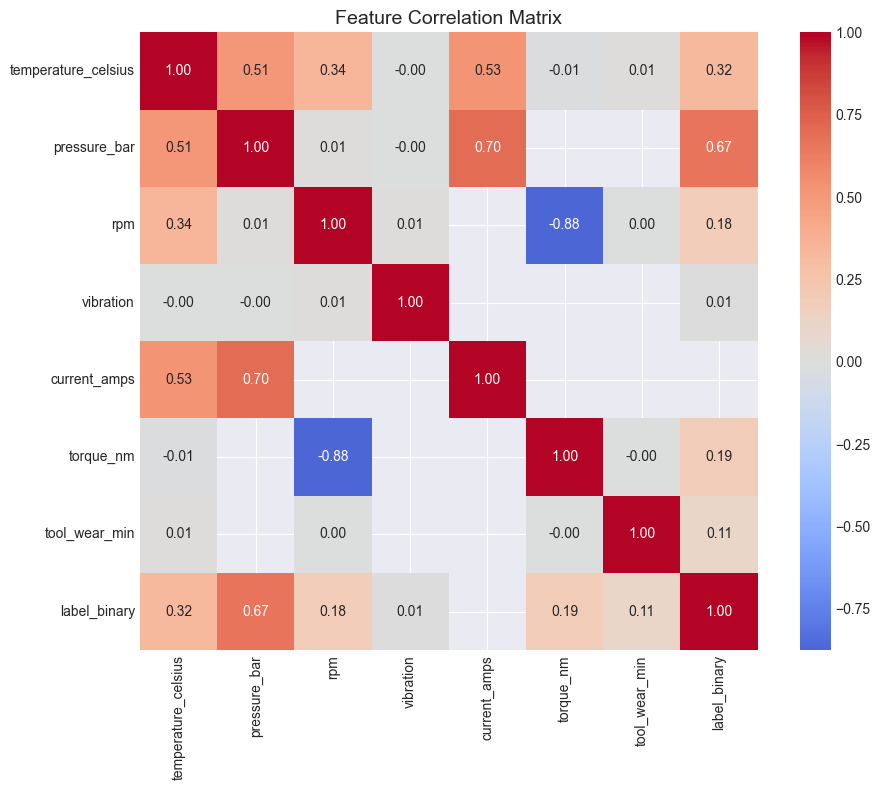


🔍 Features most correlated with failure:
  pressure_bar        :   0.6681 (strong, positive)
  temperature_celsius :   0.3198 (strong, positive)
  torque_nm           :   0.1913 (moderate, positive)
  rpm                 :   0.1831 (moderate, positive)
  tool_wear_min       :   0.1054 (moderate, positive)
  vibration           :   0.0076 (weak, positive)
  current_amps        :      nan (weak, negative)


In [35]:
# Cell 6: Correlation Matrix (with seaborn)
import seaborn as sns

plt.figure(figsize=(10, 8))
correlation_matrix = data[numeric_cols + ['label_binary']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

# Print correlations with failure
print("\n🔍 Features most correlated with failure:")
corr_with_failure = correlation_matrix['label_binary'].drop('label_binary').sort_values(ascending=False)
for feature, corr in corr_with_failure.items():
    strength = "strong" if abs(corr) > 0.3 else "moderate" if abs(corr) > 0.1 else "weak"
    direction = "positive" if corr > 0 else "negative"
    print(f"  {feature:20s}: {corr:8.4f} ({strength}, {direction})")

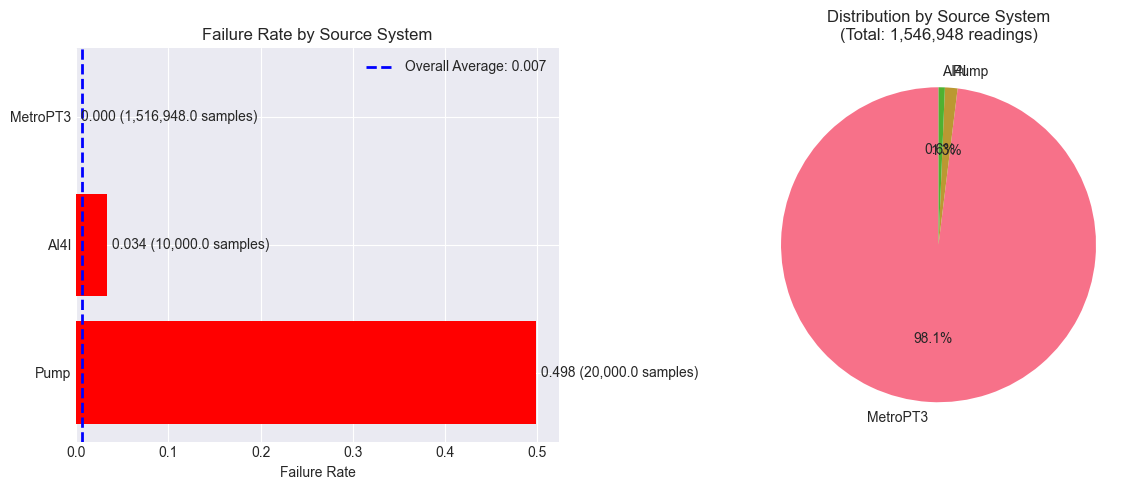


📊 Source System Statistics:
                 mean    count
source_system                 
Pump           0.4984    20000
AI4I           0.0339    10000
MetroPT3       0.0000  1516948


In [36]:
# Cell 7: Source System Analysis
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Failure rate by source system
failure_by_source = data.groupby('source_system')['label_binary'].agg(['mean', 'count']).sort_values('mean', ascending=False)

# Bar plot
colors = ['red' if x > data['label_binary'].mean() else 'green' for x in failure_by_source['mean']]
axes[0].barh(range(len(failure_by_source)), failure_by_source['mean'], color=colors)
axes[0].set_yticks(range(len(failure_by_source)))
axes[0].set_yticklabels(failure_by_source.index)
axes[0].set_xlabel('Failure Rate')
axes[0].set_title('Failure Rate by Source System')
axes[0].axvline(data['label_binary'].mean(), color='blue', linestyle='--', linewidth=2, label=f'Overall Average: {data["label_binary"].mean():.3f}')
axes[0].legend()

# Add value labels
for i, (idx, row) in enumerate(failure_by_source.iterrows()):
    axes[0].text(row['mean'] + 0.001, i, f' {row["mean"]:.3f} ({row["count"]:,} samples)', va='center')

# Count of readings by source system
count_by_source = data['source_system'].value_counts()
axes[1].pie(count_by_source.values, labels=count_by_source.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title(f'Distribution by Source System\n(Total: {len(data):,} readings)')

plt.tight_layout()
plt.show()

print("\n📊 Source System Statistics:")
print(failure_by_source)

In [37]:
# Cell 8: Define Preprocessor and Models
def build_preprocessor() -> ColumnTransformer:
    """Build preprocessing pipeline"""
    numeric_features = [col for col in FEATURE_COLUMNS if col != "source_system"]
    return ColumnTransformer(
        transformers=[
            ("numeric", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]), numeric_features),
            ("categorical", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore")),
            ]), ["source_system"]),
        ]
    )

def get_models() -> dict[str, Pipeline]:
    """Get dictionary of models"""
    preprocessor = build_preprocessor()
    return {
        "Random Forest": Pipeline([
            ("preprocessor", preprocessor),
            ("model", RandomForestClassifier(
                n_estimators=250, max_depth=10, min_samples_leaf=3,
                class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
            )),
        ]),
        "Gradient Boosting": Pipeline([
            ("preprocessor", preprocessor),
            ("model", GradientBoostingClassifier(
                n_estimators=180, learning_rate=0.06, max_depth=3, random_state=RANDOM_STATE
            )),
        ]),
        "Deep Neural Network": Pipeline([
            ("preprocessor", preprocessor),
            ("model", MLPClassifier(
                hidden_layer_sizes=(64, 32, 16), activation="relu", solver="adam",
                alpha=0.001, learning_rate_init=0.001, max_iter=350, early_stopping=True,
                validation_fraction=0.15, n_iter_no_change=20, random_state=RANDOM_STATE
            )),
        ]),
    }

In [38]:
# Cell 9: Train-Test Split
data = data.copy()
data["label_binary"] = data["label_binary"].astype(int)
X = data[FEATURE_COLUMNS]
y = data["label_binary"]

# Handle class imbalance for stratification
stratify = y if y.nunique() == 2 and y.value_counts().min() >= 2 else None

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=stratify
)

print(f"Training set size: {len(X_train):,}")
print(f"Test set size: {len(X_test):,}")
print(f"Training failure rate: {y_train.mean()*100:.2f}%")
print(f"Test failure rate: {y_test.mean()*100:.2f}%")

Training set size: 1,160,211
Test set size: 386,737
Training failure rate: 0.67%
Test failure rate: 0.67%


In [39]:
# Cell 10: Train Models and Collect Predictions
models = get_models()
trained_models = {}
predictions = {}
probabilities = {}
metrics_list = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    trained_models[name] = model
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    predictions[name] = y_pred
    probabilities[name] = y_prob
    
    # Calculate metrics
    metrics_list.append({
        'algorithm': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred, pos_label=1, zero_division=0),
        'confusion_matrix': confusion_matrix(y_test, y_pred).tolist()
    })
    
    print(f"✅ {name} - Accuracy: {metrics_list[-1]['accuracy']:.4f}, F1: {metrics_list[-1]['f1_score']:.4f}")

metrics_df = pd.DataFrame(metrics_list).sort_values('f1_score', ascending=False)
print("\n" + "="*50)
print("Model Performance Summary:")
print(metrics_df.to_string(index=False))


Training Random Forest...
✅ Random Forest - Accuracy: 0.9931, F1: 0.6594

Training Gradient Boosting...
✅ Gradient Boosting - Accuracy: 0.9933, F1: 0.3668

Training Deep Neural Network...
✅ Deep Neural Network - Accuracy: 0.9933, F1: 0.2952

Model Performance Summary:
          algorithm  accuracy  f1_score             confusion_matrix
      Random Forest  0.993145  0.659386 [[381520, 2640], [11, 2566]]
  Gradient Boosting  0.993339  0.366765 [[383415, 745], [1831, 746]]
Deep Neural Network  0.993344  0.295181 [[383624, 536], [2038, 539]]


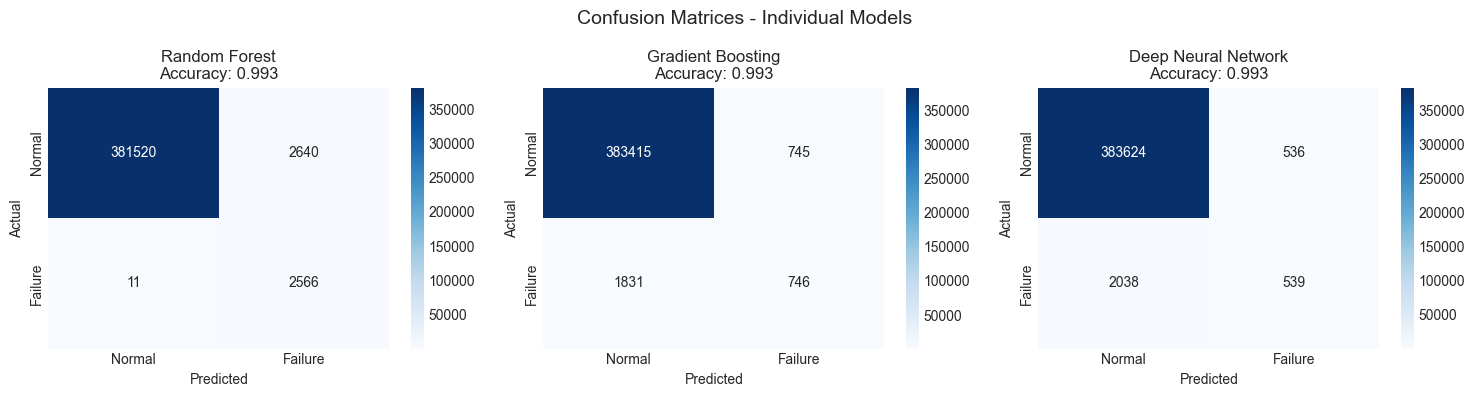

In [40]:
# Cell 11: Plot Individual Model Results - Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Normal', 'Failure'], yticklabels=['Normal', 'Failure'])
    axes[idx].set_title(f'{name}\nAccuracy: {accuracy_score(y_test, y_pred):.3f}')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.suptitle('Confusion Matrices - Individual Models', fontsize=14)
plt.tight_layout()
plt.show()

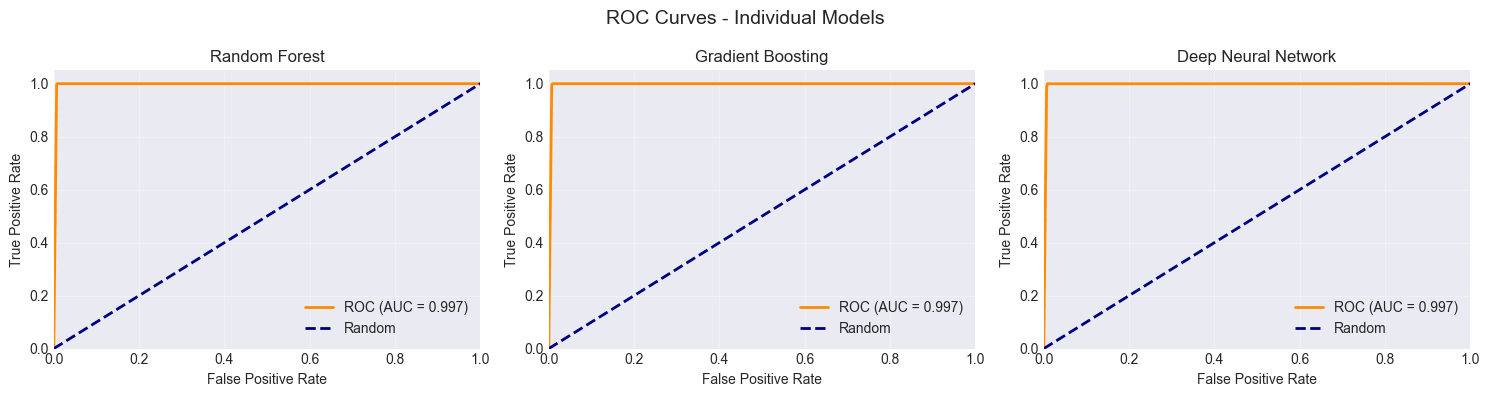

In [41]:
# Cell 12: Plot Individual Model Results - ROC Curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (name, y_prob) in enumerate(probabilities.items()):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    axes[idx].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
    axes[idx].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
    axes[idx].set_xlim([0.0, 1.0])
    axes[idx].set_ylim([0.0, 1.05])
    axes[idx].set_xlabel('False Positive Rate')
    axes[idx].set_ylabel('True Positive Rate')
    axes[idx].set_title(f'{name}')
    axes[idx].legend(loc="lower right")
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('ROC Curves - Individual Models', fontsize=14)
plt.tight_layout()
plt.show()

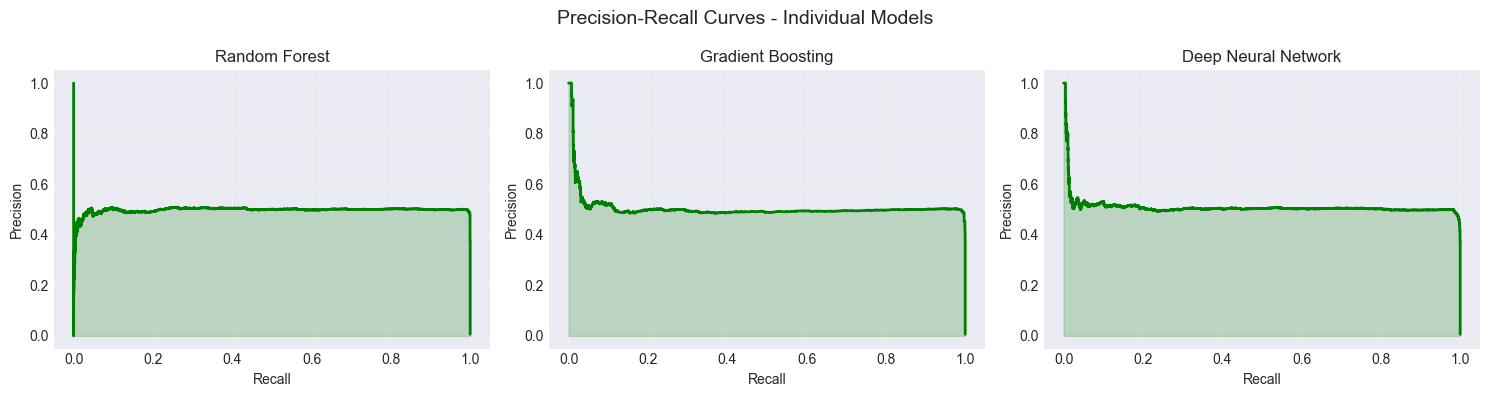

In [42]:
# Cell 13: Plot Individual Model Results - Precision-Recall Curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (name, y_prob) in enumerate(probabilities.items()):
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    
    axes[idx].plot(recall, precision, color='green', lw=2)
    axes[idx].set_xlabel('Recall')
    axes[idx].set_ylabel('Precision')
    axes[idx].set_title(f'{name}')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].fill_between(recall, precision, alpha=0.2, color='green')

plt.suptitle('Precision-Recall Curves - Individual Models', fontsize=14)
plt.tight_layout()
plt.show()

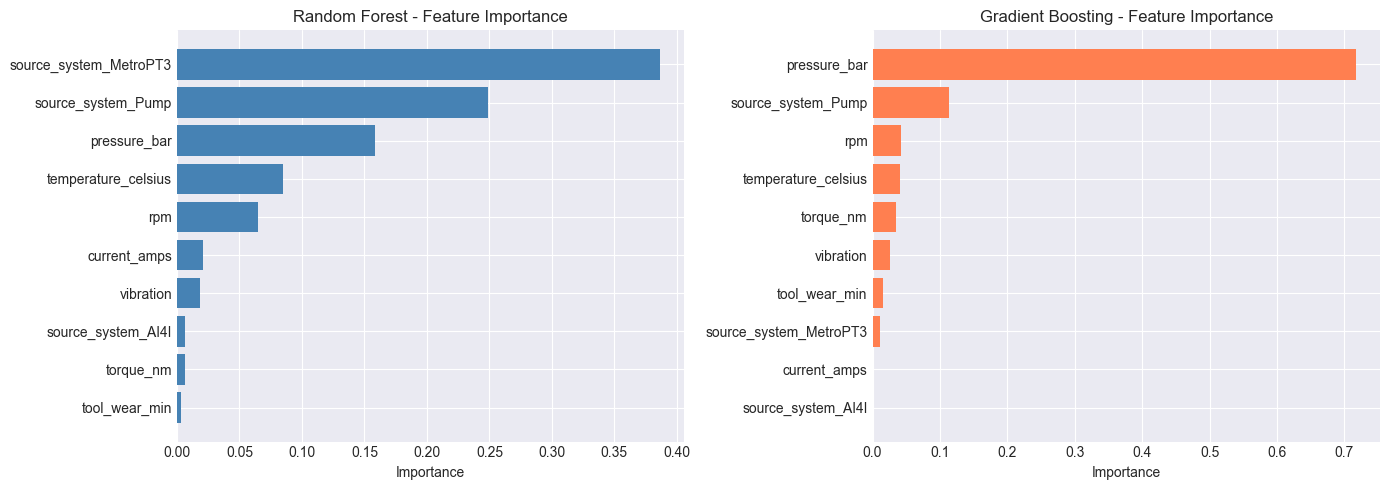

In [43]:
# Cell 14: Plot Individual Model Results - Feature Importance (for tree-based models)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Get feature names after preprocessing
preprocessor = build_preprocessor()
preprocessor.fit(X_train)
feature_names = (numeric_cols + 
                 list(preprocessor.named_transformers_['categorical'].named_steps['encoder']
                      .get_feature_names_out(['source_system'])))

# Random Forest Feature Importance
rf_model = trained_models['Random Forest'].named_steps['model']
rf_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=True)

axes[0].barh(rf_importance['feature'], rf_importance['importance'], color='steelblue')
axes[0].set_title('Random Forest - Feature Importance')
axes[0].set_xlabel('Importance')

# Gradient Boosting Feature Importance
gb_model = trained_models['Gradient Boosting'].named_steps['model']
gb_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': gb_model.feature_importances_
}).sort_values('importance', ascending=True)

axes[1].barh(gb_importance['feature'], gb_importance['importance'], color='coral')
axes[1].set_title('Gradient Boosting - Feature Importance')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

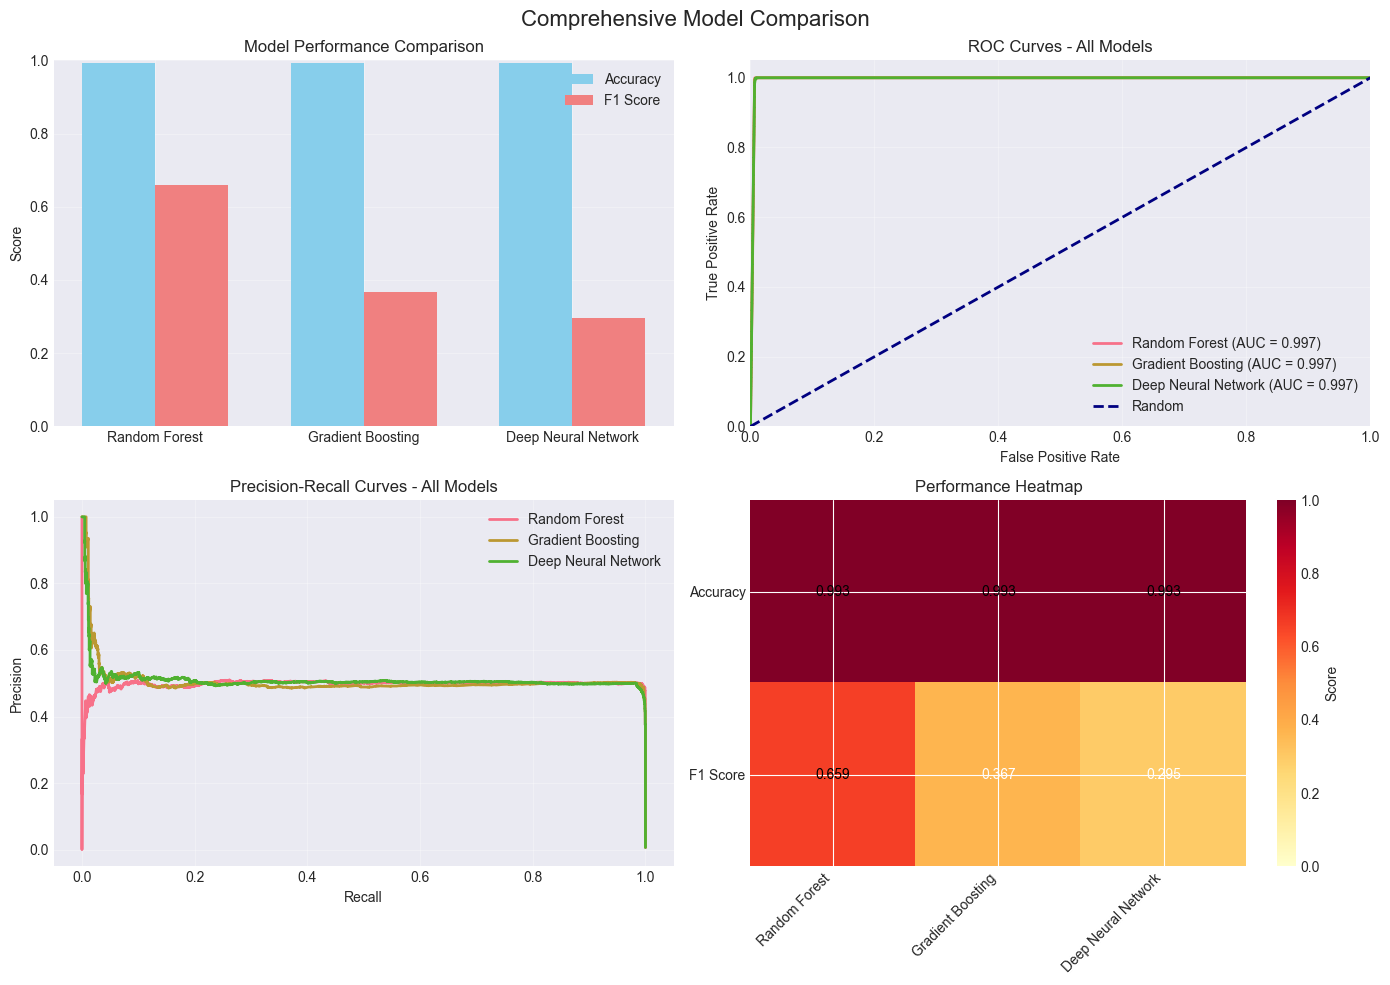

In [47]:
# Cell 15: Combined Model Comparison - Multiple Metrics (CORRECTED)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Accuracy and F1 Score Comparison
x = np.arange(len(metrics_df))
width = 0.35

axes[0,0].bar(x - width/2, metrics_df['accuracy'], width, label='Accuracy', color='skyblue')
axes[0,0].bar(x + width/2, metrics_df['f1_score'], width, label='F1 Score', color='lightcoral')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(metrics_df['algorithm'])
axes[0,0].set_ylabel('Score')
axes[0,0].set_title('Model Performance Comparison')
axes[0,0].legend()
axes[0,0].set_ylim([0, 1])
axes[0,0].grid(True, alpha=0.3)  # Changed from alpha=3 to alpha=0.3

# 2. Combined ROC Curves
for name, y_prob in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    axes[0,1].plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

axes[0,1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
axes[0,1].set_xlim([0.0, 1.0])
axes[0,1].set_ylim([0.0, 1.05])
axes[0,1].set_xlabel('False Positive Rate')
axes[0,1].set_ylabel('True Positive Rate')
axes[0,1].set_title('ROC Curves - All Models')
axes[0,1].legend(loc="lower right")
axes[0,1].grid(True, alpha=0.3)  # Changed from alpha=3 to alpha=0.3

# 3. Combined Precision-Recall Curves
for name, y_prob in probabilities.items():
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    axes[1,0].plot(recall, precision, lw=2, label=name)

axes[1,0].set_xlabel('Recall')
axes[1,0].set_ylabel('Precision')
axes[1,0].set_title('Precision-Recall Curves - All Models')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)  # Changed from alpha=3 to alpha=0.3

# 4. Performance Heatmap (matplotlib only version)
performance_data = metrics_df[['accuracy', 'f1_score']].T.values
im = axes[1,1].imshow(performance_data, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
axes[1,1].set_xticks(range(len(metrics_df['algorithm'])))
axes[1,1].set_yticks([0, 1])
axes[1,1].set_xticklabels(metrics_df['algorithm'], rotation=45, ha='right')
axes[1,1].set_yticklabels(['Accuracy', 'F1 Score'])
axes[1,1].set_title('Performance Heatmap')

# Add text annotations
for i in range(2):
    for j in range(len(metrics_df)):
        axes[1,1].text(j, i, f'{performance_data[i, j]:.3f}', ha='center', va='center', 
                      color='white' if performance_data[i, j] < 0.5 else 'black')

plt.colorbar(im, ax=axes[1,1], label='Score')

plt.suptitle('Comprehensive Model Comparison', fontsize=16)
plt.tight_layout()
plt.show()

In [48]:
# Cell 16: Score All Equipment and Generate Maintenance Plan
def make_status_label(failure_probability: float) -> str:
    if failure_probability >= 0.70:
        return "failure imminent"
    elif failure_probability >= 0.35:
        return "maintenance required"
    return "normal"

def make_strategy(row: pd.Series) -> str:
    if row["predicted_status"] == "failure imminent":
        return " Stop or isolate equipment, inspect within 24 hours, and prepare spare parts."
    elif row["predicted_status"] == "maintenance required":
        return " Schedule preventive maintenance in the next service window and monitor sensor trend."
    return " Continue normal operation with routine monitoring."

# Select best model
best_model_name = metrics_df.iloc[0]['algorithm']
best_model = trained_models[best_model_name]

print(f"Using best model: {best_model_name}")

# Score all equipment
probabilities_full = best_model.predict_proba(X)[:, 1]
scored_data = data.copy()
scored_data["failure_probability"] = probabilities_full
scored_data["predicted_status"] = scored_data["failure_probability"].apply(make_status_label)
scored_data["maintenance_strategy"] = scored_data.apply(make_strategy, axis=1)

maintenance_plan = scored_data[[
    "measurement_id", "equipment_key", "time_key", "source_system",
    "failure_probability", "predicted_status", "maintenance_strategy", "failure_type"
]].sort_values("failure_probability", ascending=False)

print(f"\nMaintenance plan generated for {len(maintenance_plan):,} measurements")
print(f"\nStatus Distribution:")
print(maintenance_plan['predicted_status'].value_counts())
maintenance_plan.head(10)

Using best model: Random Forest

Maintenance plan generated for 1,546,948 measurements

Status Distribution:
predicted_status
normal                  1525760
failure imminent          20495
maintenance required        693
Name: count, dtype: int64


,measurement_id,equipment_key,time_key,source_system,failure_probability,predicted_status,maintenance_strategy,failure_type
1529940,1529941,23556,2024010301,Pump,0.995043,failure imminent,"Stop or isolate equipment, inspect within 24 ...",Pump_Failure
1545939,1545940,23555,2024011404,Pump,0.994952,failure imminent,"Stop or isolate equipment, inspect within 24 ...",Pump_Failure
1545102,1545103,23557,2024011314,Pump,0.994932,failure imminent,"Stop or isolate equipment, inspect within 24 ...",Pump_Failure
1531397,1531398,23555,2024010402,Pump,0.994904,failure imminent,"Stop or isolate equipment, inspect within 24 ...",Pump_Failure
1531332,1531333,23557,2024010401,Pump,0.994774,failure imminent,"Stop or isolate equipment, inspect within 24 ...",Pump_Failure
1528450,1528451,23557,2024010201,Pump,0.994741,failure imminent,"Stop or isolate equipment, inspect within 24 ...",Pump_Failure
1530427,1530428,23556,2024010309,Pump,0.994728,failure imminent,"Stop or isolate equipment, inspect within 24 ...",Pump_Failure
1533493,1533494,23556,2024010513,Pump,0.994709,failure imminent,"Stop or isolate equipment, inspect within 24 ...",Pump_Failure
1535133,1535134,23553,2024010616,Pump,0.994698,failure imminent,"Stop or isolate equipment, inspect within 24 ...",Pump_Failure
1529527,1529528,23555,2024010218,Pump,0.994673,failure imminent,"Stop or isolate equipment, inspect within 24 ...",Pump_Failure


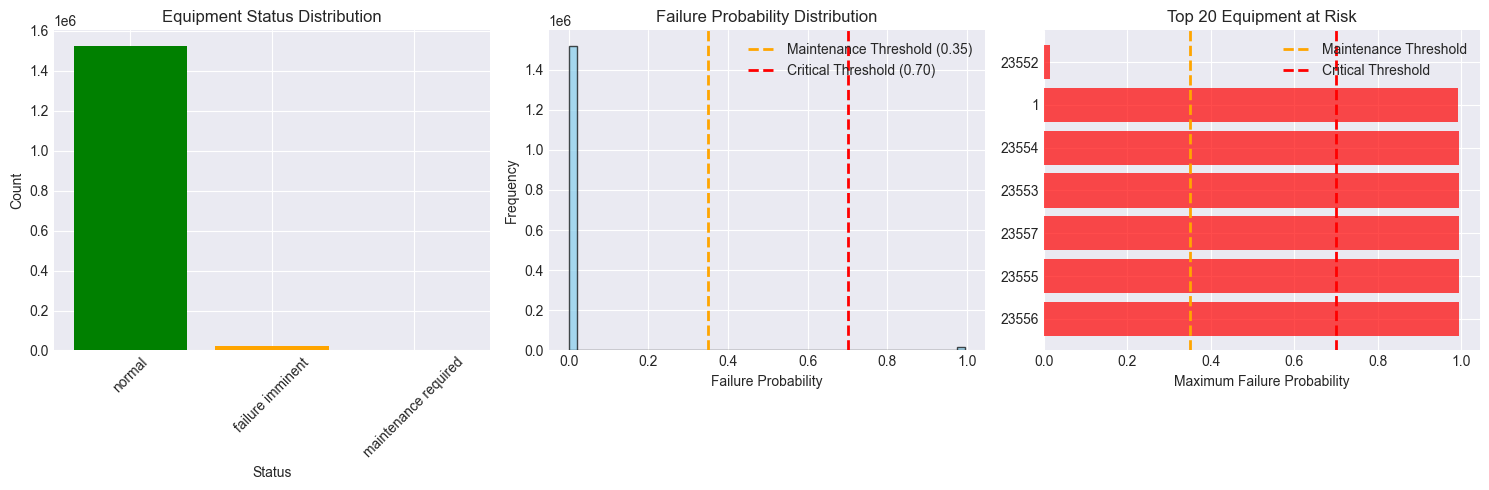

In [49]:
# Cell 17: Visualization of Maintenance Recommendations
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Status Distribution
status_counts = maintenance_plan['predicted_status'].value_counts()
colors = ['green', 'orange', 'red']
axes[0].bar(status_counts.index, status_counts.values, color=colors)
axes[0].set_title('Equipment Status Distribution')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# 2. Failure Probability Distribution
axes[1].hist(maintenance_plan['failure_probability'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[1].axvline(0.35, color='orange', linestyle='--', linewidth=2, label='Maintenance Threshold (0.35)')
axes[1].axvline(0.70, color='red', linestyle='--', linewidth=2, label='Critical Threshold (0.70)')
axes[1].set_xlabel('Failure Probability')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Failure Probability Distribution')
axes[1].legend()

# 3. Top 20 Equipment at Risk
top_equipment = maintenance_plan.groupby('equipment_key')['failure_probability'].max().sort_values(ascending=False).head(20)
axes[2].barh(range(len(top_equipment)), top_equipment.values, color='red', alpha=0.7)
axes[2].set_yticks(range(len(top_equipment)))
axes[2].set_yticklabels(top_equipment.index.astype(int))
axes[2].set_xlabel('Maximum Failure Probability')
axes[2].set_title('Top 20 Equipment at Risk')
axes[2].axvline(0.35, color='orange', linestyle='--', linewidth=2, label='Maintenance Threshold')
axes[2].axvline(0.70, color='red', linestyle='--', linewidth=2, label='Critical Threshold')
axes[2].legend()

plt.tight_layout()
plt.show()

In [50]:
# Cell 18: Save Outputs
output_dir = Path("model_outputs")
output_dir.mkdir(parents=True, exist_ok=True)

# Save metrics
metrics_df.to_csv(output_dir / "model_metrics.csv", index=False)

# Save maintenance recommendations
maintenance_plan.to_csv(output_dir / "maintenance_recommendations.csv", index=False)

# Save best model
joblib.dump(best_model, output_dir / "best_failure_classifier.joblib")

# Save summary report
summary = f"""# Predictive Maintenance Modeling Summary

## Overview
- **Data source**: {data_source}
- **Total samples**: {len(data):,}
- **Failure rate**: {data['label_binary'].mean()*100:.2f}%
- **Best algorithm**: {best_model_name}

## Model Performance
{metrics_df[['algorithm', 'accuracy', 'f1_score']].to_string(index=False)}

## Status Distribution
{maintenance_plan['predicted_status'].value_counts().to_string()}

## Critical Alerts
- **Failure Imminent**: {(maintenance_plan['predicted_status'] == 'failure imminent').sum():,} measurements
- **Maintenance Required**: {(maintenance_plan['predicted_status'] == 'maintenance required').sum():,} measurements
- **Normal**: {(maintenance_plan['predicted_status'] == 'normal').sum():,} measurements

## Generated Files
- `model_metrics.csv` - Performance metrics for all models
- `maintenance_recommendations.csv` - Detailed recommendations for all equipment
- `best_failure_classifier.joblib` - Trained best model for deployment

## Rules Applied
- **Normal**: failure probability < 35%
- **Maintenance required**: 35% ≤ failure probability < 70%
- **Failure imminent**: failure probability ≥ 70%
"""

(output_dir / "modeling_summary.md").write_text(summary, encoding="utf-8")

print(f" All outputs saved to: {output_dir.resolve()}")
print("\nGenerated files:")
for file in output_dir.glob("*"):
    print(f"  - {file.name}")

 All outputs saved to: C:\Users\wesal\OneDrive\Desktop\Bachelor\Junior-Spring\Data Mining\predictive maintenance\model_outputs

Generated files:
  - best_failure_classifier.joblib
  - maintenance_recommendations.csv
  - modeling_summary.md
  - model_metrics.csv


In [53]:
# Cell 19: Interactive Predictions (Optional)
def predict_single_measurement(temperature, pressure, rpm, vibration, current, torque, tool_wear, source_system):
    """Make prediction for a single measurement"""
    input_data = pd.DataFrame({
        'source_system': [source_system],
        'temperature_celsius': [temperature],
        'pressure_bar': [pressure],
        'rpm': [rpm],
        'vibration': [vibration],
        'current_amps': [current],
        'torque_nm': [torque],
        'tool_wear_min': [tool_wear]
    })
    
    prob = best_model.predict_proba(input_data)[0, 1]
    status = make_status_label(prob)
    strategy = make_strategy(pd.Series({'predicted_status': status}))
    
    print(f"\n{'='*50}")
    print(f"PREDICTION RESULTS")
    print(f"{'='*50}")
    print(f"Failure Probability: {prob:.2%}")
    print(f"Status: {status.upper()}")
    print(f"Strategy: {strategy}")
    print(f"{'='*50}\n")
    
    return prob, status, strategy

# Example usage (uncomment to test)
predict_single_measurement(
    temperature=85, pressure=12, rpm=2100, vibration=3.5,
    current=6.5, torque=55, tool_wear=200, source_system='AI4I'
)


PREDICTION RESULTS
Failure Probability: 22.79%
Status: NORMAL
Strategy:  Continue normal operation with routine monitoring.



(np.float64(0.227856889347212),
 'normal',
 ' Continue normal operation with routine monitoring.')